# VCIP Weakness Analysis (Step 3)

Systematic identification of VCIP's limitations as candidate directions for a NeurIPS extension.

**Data sources:**
- MIMIC-III results: 5 models x 5 seeds, tau={2,4,6,8} (full replication)
- Cancer simulation: 5 models x 5 seeds, gamma=1..4 (full replication with ground-truth counterfactuals)
- VCIP paper: Tables 1-3, Figures 3-6

**Analysis structure:**
1. ELBO calibration: does lower ELBO reliably predict better outcomes?
2. Per-individual failure modes: characterize when VCIP fails
3. Sensitivity to prediction horizon and perturbation count
4. Theoretical limitations: what the ELBO-based ranking fundamentally cannot capture
5. Confounding sensitivity: how does performance degrade with confounding strength?
6. Synthesis: ranked list of weaknesses and research directions

In [1]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter

# Paths
MIMIC_BASE = Path('../my_outputs/mimic_real')
CANCER_BASE = Path('../my_outputs/cancer_sim_cont/22')

SEEDS = [10, 101, 1010, 10101, 101010]
MODELS_ORDER = ['VCIP', 'ACTIN', 'CT', 'CRN', 'RMSN']
TAU_VALUES = [2, 4, 6, 8]
GAMMAS = [1, 2, 3, 4]

MIMIC_PATHS = {
    'VCIP':  'VCIP/train/case_infos/{seed}/False/case_infos_VCIP.pkl',
    'ACTIN': 'ACTIN/0.01/train/case_infos/{seed}/False/case_infos_ACTIN.pkl',
    'CRN':   'CRN/0.01/train/case_infos/{seed}/False/case_infos_CRN.pkl',
    'CT':    'CT/0.01/train/case_infos/{seed}/False/case_infos_CT.pkl',
    'RMSN':  'RMSN/train/case_infos/{seed}/False/case_infos_RMSN.pkl',
}

def load_case_infos(base_dir, paths, seeds, models):
    all_data = {}
    for model in models:
        all_data[model] = {}
        for seed in seeds:
            pkl_path = base_dir / paths[model].format(seed=seed)
            if not pkl_path.exists():
                continue
            with open(pkl_path, 'rb') as f:
                data = pickle.load(f)
            inner = data[model]
            for tau, cases in inner.items():
                if tau not in all_data[model]:
                    all_data[model][tau] = []
                all_data[model][tau].extend(cases)
    return all_data

mimic_data = load_case_infos(MIMIC_BASE, MIMIC_PATHS, SEEDS, MODELS_ORDER)

# Cancer: load all models, all gammas, all seeds
def load_cancer_case_infos(base_dir, gammas, seeds):
    """Load Cancer case_infos for all models, gammas, seeds."""
    base_path = Path(base_dir)
    all_data = {}  # {gamma: {model: {tau: [cases]}}}
    for gamma in gammas:
        coeff_dir = base_path / f'coeff_{gamma}'
        all_data[gamma] = {}
        for model_dir in coeff_dir.iterdir():
            if not model_dir.is_dir():
                continue
            model_name = model_dir.name
            all_data[gamma][model_name] = {}
            for case_dir in model_dir.rglob('case_infos'):
                for seed_dir in case_dir.iterdir():
                    if not seed_dir.is_dir():
                        continue
                    pkl = seed_dir / 'False' / f'case_infos_{model_name}.pkl'
                    if pkl.exists():
                        with open(pkl, 'rb') as f:
                            data = pickle.load(f)
                        key = list(data.keys())[0]
                        for tau, cases in data[key].items():
                            if tau not in all_data[gamma][model_name]:
                                all_data[gamma][model_name][tau] = []
                            all_data[gamma][model_name][tau].extend(cases)
    return all_data

cancer_all = load_cancer_case_infos(CANCER_BASE, GAMMAS, SEEDS)
# Keep backward-compatible reference for sections that use cancer_data
cancer_data = {'VCIP': cancer_all[4]['VCIP']}

print('MIMIC data loaded:', {m: sorted(mimic_data[m].keys()) for m in MODELS_ORDER})
print('Cancer data loaded:')
for g in GAMMAS:
    models = sorted(cancer_all[g].keys())
    print(f'  gamma={g}: {models}')

MIMIC data loaded: {'VCIP': [2, 4, 6, 8], 'ACTIN': [2, 4, 6, 8], 'CT': [2, 4, 6, 8], 'CRN': [2, 4, 6, 8], 'RMSN': [2, 4, 6, 8]}
Cancer data loaded:
  gamma=1: ['ACTIN', 'CRN', 'CT', 'RMSN', 'VCIP']
  gamma=2: ['ACTIN', 'CRN', 'CT', 'RMSN', 'VCIP']
  gamma=3: ['ACTIN', 'CRN', 'CT', 'RMSN', 'VCIP']
  gamma=4: ['ACTIN', 'CRN', 'CT', 'RMSN', 'RMSN_ab', 'VCIP', 'VCIP_ablation']


## 1. ELBO Calibration Analysis

**Core question:** Does lower ELBO loss reliably predict better actual outcomes?

On Cancer data (where true counterfactual outcomes are observable), we can directly check whether the ELBO-based ranking correlates with the true outcome ranking. On MIMIC (where counterfactuals are unobservable), we can only examine the ELBO's internal consistency.

### 1a. Cancer: ELBO vs. True Target Distance (Ground Truth Available)

/opt/homebrew/anaconda3/envs/target-counterfactual-env/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


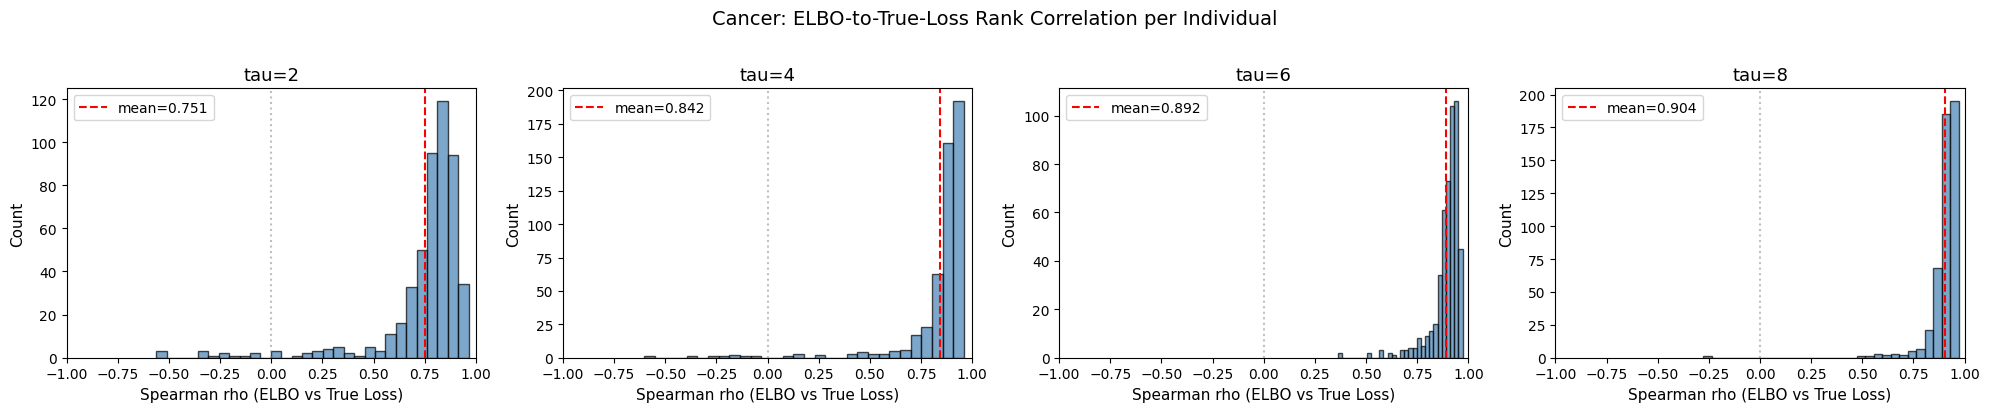


ELBO-True Loss Spearman correlation (Cancer, VCIP):
  tau=2: mean=0.751, median=0.812, std=0.226, fraction > 0: 0.974
  tau=4: mean=0.842, median=0.891, std=0.182, fraction > 0: 0.984
  tau=6: mean=0.892, median=0.913, std=0.076, fraction > 0: 1.000
  tau=8: mean=0.904, median=0.922, std=0.082, fraction > 0: 0.998


In [2]:
# Cancer dataset: compare ELBO ranking vs true outcome ranking
# For each individual, we have 100 candidate sequences with both model_losses (ELBO) and true_losses

fig, axes = plt.subplots(1, len(TAU_VALUES), figsize=(20, 4))

correlations_by_tau = {}

for ax_idx, tau in enumerate(TAU_VALUES):
    ax = axes[ax_idx]
    cases = cancer_data['VCIP'][tau]
    
    spearman_rs = []
    for c in cases:
        model_losses = c['model_losses']  # ELBO losses
        true_losses = c['true_losses']    # True target distances
        
        # Spearman correlation between ELBO ranking and true ranking
        rho, pval = stats.spearmanr(model_losses, true_losses)
        if not np.isnan(rho):
            spearman_rs.append(rho)
    
    correlations_by_tau[tau] = spearman_rs
    
    ax.hist(spearman_rs, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(x=np.mean(spearman_rs), color='red', linestyle='--', 
               label=f'mean={np.mean(spearman_rs):.3f}')
    ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Spearman rho (ELBO vs True Loss)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'tau={tau}', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xlim(-1, 1)

plt.suptitle('Cancer: ELBO-to-True-Loss Rank Correlation per Individual', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('weakness_elbo_calibration_cancer.pdf', dpi=300, bbox_inches='tight')
plt.show()

print('\nELBO-True Loss Spearman correlation (Cancer, VCIP):')
for tau in TAU_VALUES:
    rs = correlations_by_tau[tau]
    print(f'  tau={tau}: mean={np.mean(rs):.3f}, median={np.median(rs):.3f}, '
          f'std={np.std(rs):.3f}, fraction > 0: {np.mean(np.array(rs) > 0):.3f}')

/opt/homebrew/anaconda3/envs/target-counterfactual-env/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


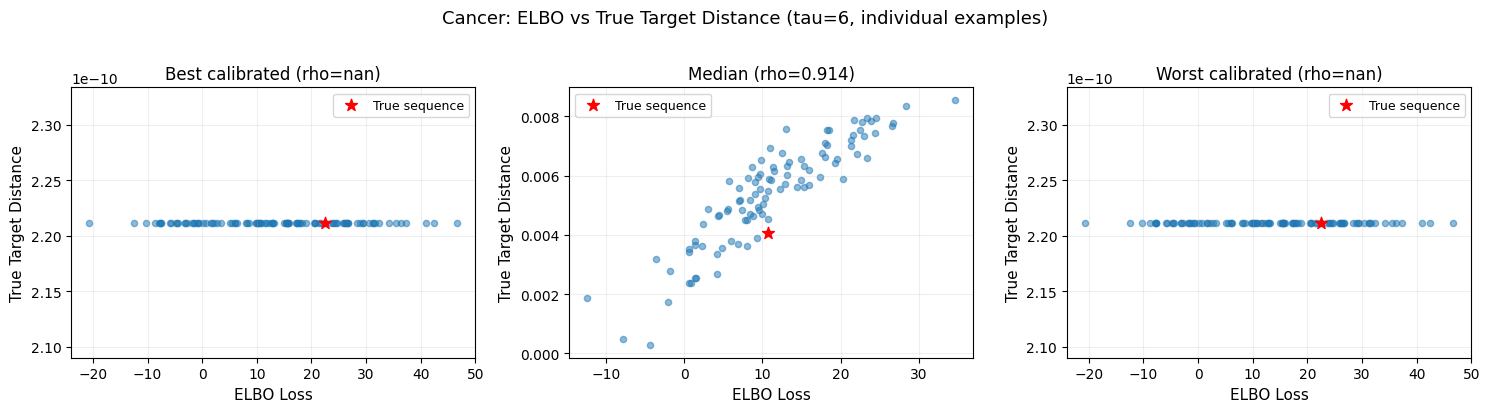

In [3]:
# Scatter: ELBO loss vs True loss for a representative individual (Cancer)
tau_show = 6
cases = cancer_data['VCIP'][tau_show]

# Pick individual with median correlation
rs = [stats.spearmanr(c['model_losses'], c['true_losses'])[0] for c in cases]
median_idx = np.argsort(rs)[len(rs)//2]
# Also pick worst and best
best_idx = np.argmax(rs)
worst_idx = np.argmin(rs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx, label in zip(axes, [best_idx, median_idx, worst_idx], 
                            ['Best calibrated', 'Median', 'Worst calibrated']):
    c = cases[idx]
    ax.scatter(c['model_losses'], c['true_losses'], alpha=0.5, s=20)
    rho = stats.spearmanr(c['model_losses'], c['true_losses'])[0]
    ax.set_xlabel('ELBO Loss', fontsize=11)
    ax.set_ylabel('True Target Distance', fontsize=11)
    ax.set_title(f'{label} (rho={rho:.3f})', fontsize=12)
    ax.grid(True, alpha=0.2)
    
    # Highlight true sequence
    true_rank = c['true_sequence_rank']
    ax.scatter(c['model_losses'][0], c['true_losses'][0], 
               color='red', s=80, zorder=5, marker='*', label='True sequence')
    ax.legend(fontsize=9)

plt.suptitle(f'Cancer: ELBO vs True Target Distance (tau={tau_show}, individual examples)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('weakness_elbo_scatter_cancer.pdf', dpi=300, bbox_inches='tight')
plt.show()

### 1b. MIMIC: ELBO Internal Consistency

On real-world data, true counterfactuals are unobservable. We analyze ELBO's discrimination power: how clearly does ELBO separate the true sequence from random perturbations?

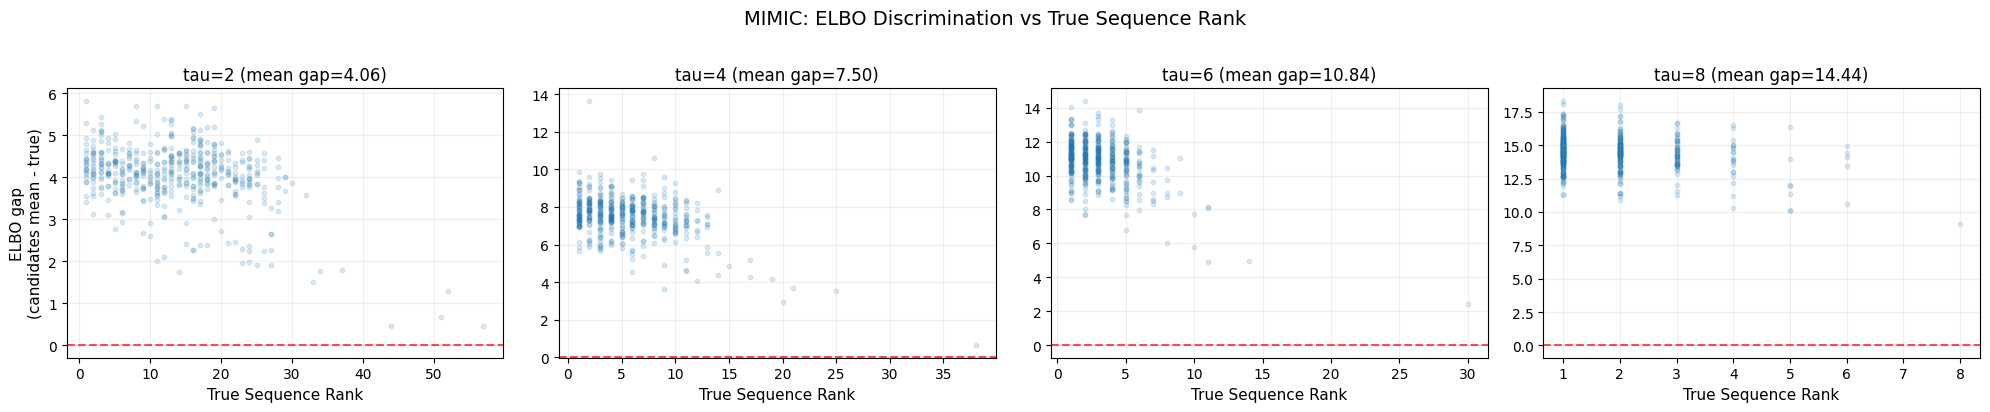

In [4]:
# MIMIC: ELBO gap analysis across all tau values
fig, axes = plt.subplots(1, len(TAU_VALUES), figsize=(20, 4))

for ax_idx, tau in enumerate(TAU_VALUES):
    ax = axes[ax_idx]
    vcip_cases = mimic_data['VCIP'][tau]
    
    true_elbos = []
    mean_candidate_elbos = []
    ranks = []
    
    for c in vcip_cases:
        ml = c['model_losses']
        # Sort to find where true sequence sits
        true_elbo = ml[0]  # first entry is true sequence if rank=1
        # Actually, model_losses are not sorted by rank. Let's use true_sequence_rank
        sorted_ml = np.sort(ml)
        true_idx = c['true_sequence_rank'] - 1  # rank is 1-indexed
        true_elbo = sorted_ml[true_idx]
        mean_cand = np.mean(np.delete(sorted_ml, true_idx))
        
        true_elbos.append(true_elbo)
        mean_candidate_elbos.append(mean_cand)
        ranks.append(c['true_sequence_rank'])
    
    true_elbos = np.array(true_elbos)
    mean_candidate_elbos = np.array(mean_candidate_elbos)
    gaps = mean_candidate_elbos - true_elbos
    
    ax.scatter(ranks, gaps, alpha=0.15, s=10)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    ax.set_xlabel('True Sequence Rank', fontsize=11)
    if ax_idx == 0:
        ax.set_ylabel('ELBO gap\n(candidates mean - true)', fontsize=11)
    ax.set_title(f'tau={tau} (mean gap={gaps.mean():.2f})', fontsize=12)
    ax.grid(True, alpha=0.2)

plt.suptitle('MIMIC: ELBO Discrimination vs True Sequence Rank', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('weakness_elbo_discrimination_mimic.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 2. Per-Individual Failure Mode Characterization

When VCIP fails (ranks the true sequence poorly), what characterizes these failures? We examine:
- Distribution of failure severity
- Whether the same individuals fail consistently across seeds
- ELBO loss magnitude in failure vs success cases

In [5]:
# Failure characterization on MIMIC (tau=2, where VCIP has most failures)
tau_analyze = 2
vcip_cases = mimic_data['VCIP'][tau_analyze]

ranks = np.array([c['true_sequence_rank'] for c in vcip_cases])
grps = (100 - ranks) / 99.0
indiv_ids = np.array([c['individual_id'] for c in vcip_cases])

# Identify persistent failures: individuals that rank poorly across seeds
failure_threshold = 50  # rank > 50 = bottom half
indiv_failure_counts = Counter()
indiv_seed_count = Counter()

for c in vcip_cases:
    iid = c['individual_id']
    indiv_seed_count[iid] += 1
    if c['true_sequence_rank'] > failure_threshold:
        indiv_failure_counts[iid] += 1

# Individuals that fail in most seeds
persistent_failures = {iid: count for iid, count in indiv_failure_counts.items() 
                       if count >= 3}  # fail in 3+ of 5 seeds

print(f'tau={tau_analyze}: {len(vcip_cases)} evaluations, {len(set(indiv_ids))} unique individuals')
print(f'Failure rate (rank > {failure_threshold}): {(ranks > failure_threshold).mean():.1%}')
print(f'Persistent failures (rank > {failure_threshold} in 3+ seeds): {len(persistent_failures)} individuals')
if persistent_failures:
    print(f'  IDs: {sorted(persistent_failures.keys())}')
    print(f'  Failure counts: {sorted(persistent_failures.values(), reverse=True)}')

# Compare ELBO magnitude in success vs failure cases
success_elbos = [c['model_losses'].mean() for c in vcip_cases if c['true_sequence_rank'] <= 5]
failure_elbos = [c['model_losses'].mean() for c in vcip_cases if c['true_sequence_rank'] > failure_threshold]

print(f'\nMean ELBO (success, rank<=5): {np.mean(success_elbos):.3f} +/- {np.std(success_elbos):.3f}')
print(f'Mean ELBO (failure, rank>{failure_threshold}): {np.mean(failure_elbos):.3f} +/- {np.std(failure_elbos):.3f}')
print(f'T-test: t={stats.ttest_ind(success_elbos, failure_elbos).statistic:.3f}, '
      f'p={stats.ttest_ind(success_elbos, failure_elbos).pvalue:.4f}')

tau=2: 500 evaluations, 100 unique individuals
Failure rate (rank > 50): 0.6%
Persistent failures (rank > 50 in 3+ seeds): 0 individuals

Mean ELBO (success, rank<=5): 5.286 +/- 1.484
Mean ELBO (failure, rank>50): 5.151 +/- 0.358
T-test: t=0.155, p=0.8770


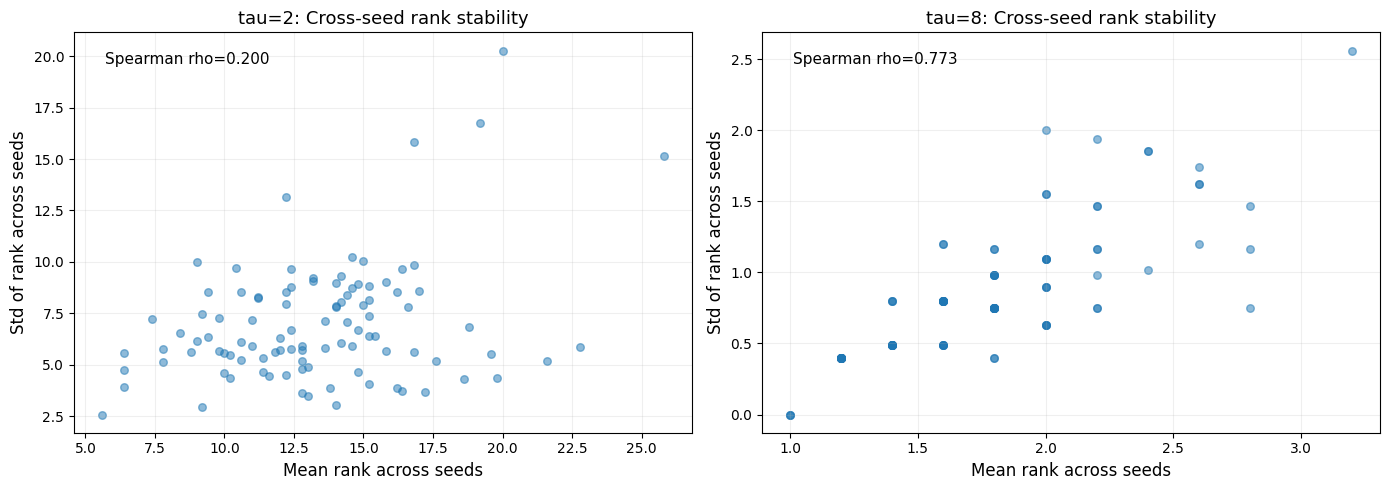

Rank stability analysis (std of rank across 5 seeds, per individual):
  tau=2: mean rank std=7.0, max=20.3, fraction with std>20: 1.00%
  tau=4: mean rank std=3.2, max=14.2, fraction with std>20: 0.00%
  tau=6: mean rank std=1.7, max=10.8, fraction with std>20: 0.00%
  tau=8: mean rank std=0.8, max=2.6, fraction with std>20: 0.00%


In [6]:
# Cross-seed consistency: does the same individual get the same rank across seeds?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, tau in enumerate([2, 8]):
    ax = axes[ax_idx]
    vcip_cases = mimic_data['VCIP'][tau]
    
    # Build individual x seed matrix
    indiv_ranks = {}  # {individual_id: [rank_seed0, rank_seed1, ...]}
    for i, c in enumerate(vcip_cases):
        iid = c['individual_id']
        if iid not in indiv_ranks:
            indiv_ranks[iid] = []
        indiv_ranks[iid].append(c['true_sequence_rank'])
    
    # Compute rank variance per individual
    rank_stds = [np.std(ranks) for iid, ranks in indiv_ranks.items() if len(ranks) == 5]
    rank_means = [np.mean(ranks) for iid, ranks in indiv_ranks.items() if len(ranks) == 5]
    
    ax.scatter(rank_means, rank_stds, alpha=0.5, s=30)
    ax.set_xlabel('Mean rank across seeds', fontsize=12)
    ax.set_ylabel('Std of rank across seeds', fontsize=12)
    ax.set_title(f'tau={tau}: Cross-seed rank stability', fontsize=13)
    ax.grid(True, alpha=0.2)
    
    # Annotate
    corr = stats.spearmanr(rank_means, rank_stds)
    ax.annotate(f'Spearman rho={corr.statistic:.3f}', xy=(0.05, 0.95), 
                xycoords='axes fraction', fontsize=11, va='top')

plt.tight_layout()
plt.savefig('weakness_rank_stability.pdf', dpi=300, bbox_inches='tight')
plt.show()

print('Rank stability analysis (std of rank across 5 seeds, per individual):')
for tau in TAU_VALUES:
    vcip_cases = mimic_data['VCIP'][tau]
    indiv_ranks = {}
    for c in vcip_cases:
        iid = c['individual_id']
        if iid not in indiv_ranks:
            indiv_ranks[iid] = []
        indiv_ranks[iid].append(c['true_sequence_rank'])
    rank_stds = [np.std(r) for r in indiv_ranks.values() if len(r) == 5]
    print(f'  tau={tau}: mean rank std={np.mean(rank_stds):.1f}, '
          f'max={np.max(rank_stds):.1f}, fraction with std>20: {np.mean(np.array(rank_stds)>20):.2%}')

## 3. VCIP's Sensitivity to Perturbation Strategy

The GRP evaluation generates k=100 random perturbations of the true treatment sequence. A crucial question: **how sensitive is the GRP metric to the perturbation distribution?**

We analyze this indirectly by examining whether VCIP's ELBO concentrates around the true sequence or is spread out — high concentration means small perturbations would be hard to distinguish.

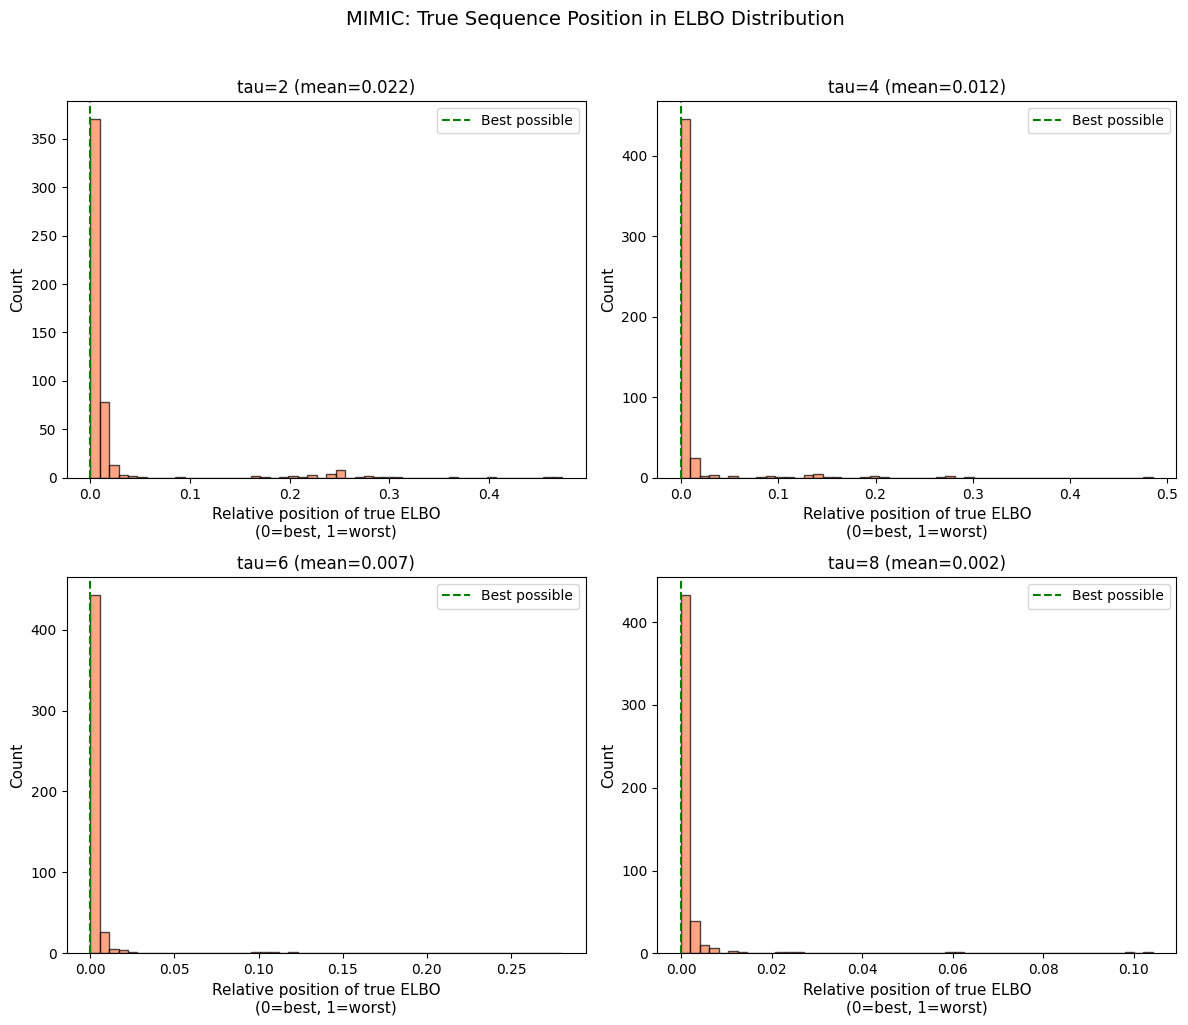

In [7]:
# ELBO loss distribution shape: how separable is the true sequence?
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax_idx, tau in enumerate(TAU_VALUES):
    ax = axes[ax_idx // 2][ax_idx % 2]
    vcip_cases = mimic_data['VCIP'][tau]
    
    # For each individual, compute: ratio of true ELBO to candidate ELBO range
    separation_ratios = []
    for c in vcip_cases:
        ml = c['model_losses']
        sorted_ml = np.sort(ml)
        true_idx = c['true_sequence_rank'] - 1
        true_elbo = sorted_ml[true_idx]
        elbo_range = sorted_ml[-1] - sorted_ml[0]
        if elbo_range > 0:
            # How far is true from minimum, relative to range?
            relative_pos = (true_elbo - sorted_ml[0]) / elbo_range
            separation_ratios.append(relative_pos)
    
    separation_ratios = np.array(separation_ratios)
    ax.hist(separation_ratios, bins=50, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(x=0, color='green', linestyle='--', label='Best possible')
    ax.set_xlabel('Relative position of true ELBO\n(0=best, 1=worst)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'tau={tau} (mean={separation_ratios.mean():.3f})', fontsize=12)
    ax.legend(fontsize=10)

plt.suptitle('MIMIC: True Sequence Position in ELBO Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('weakness_elbo_separation.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 4. Comparison: ELBO-Based vs Prediction-Based Ranking

A fundamental architectural distinction: VCIP ranks by ELBO (generative model likelihood), while baselines rank by predicted target distance. We analyze this on Cancer data where both can be compared to ground truth.

In [8]:
# Cancer: VCIP ELBO ranking vs true ranking — detailed analysis
print('Cancer VCIP: Ranking quality analysis')
print('=' * 70)

for tau in TAU_VALUES:
    cases = cancer_data['VCIP'][tau]
    
    # For each individual: rank by ELBO, rank by true loss, compare
    rank_diffs = []  # |ELBO_rank - true_rank| for each candidate
    top1_accuracy = 0  # how often ELBO's top-1 is also true top-1
    top5_accuracy = 0  # how often ELBO's top-1 is in true top-5
    
    for c in cases:
        elbo_order = np.argsort(c['model_losses'])  # ascending ELBO = better
        true_order = np.argsort(c['true_losses'])    # ascending true loss = better
        
        # Top-1 agreement
        if elbo_order[0] == true_order[0]:
            top1_accuracy += 1
        if elbo_order[0] in true_order[:5]:
            top5_accuracy += 1
        
        # Kendall tau between rankings
        elbo_ranks = np.argsort(elbo_order)
        true_ranks = np.argsort(true_order)
        rank_diffs.append(np.mean(np.abs(elbo_ranks - true_ranks)))
    
    n = len(cases)
    print(f'\ntau={tau} ({n} individuals):')
    print(f'  Top-1 agreement (ELBO best = True best): {top1_accuracy/n:.1%}')
    print(f'  Top-5 agreement (ELBO best in True top-5): {top5_accuracy/n:.1%}')
    print(f'  Mean absolute rank difference: {np.mean(rank_diffs):.1f} positions')

Cancer VCIP: Ranking quality analysis

tau=2 (500 individuals):
  Top-1 agreement (ELBO best = True best): 19.2%
  Top-5 agreement (ELBO best in True top-5): 51.6%
  Mean absolute rank difference: 14.9 positions

tau=4 (500 individuals):
  Top-1 agreement (ELBO best = True best): 42.4%
  Top-5 agreement (ELBO best in True top-5): 69.6%
  Mean absolute rank difference: 11.5 positions

tau=6 (500 individuals):
  Top-1 agreement (ELBO best = True best): 62.6%
  Top-5 agreement (ELBO best in True top-5): 84.6%
  Mean absolute rank difference: 9.8 positions

tau=8 (500 individuals):
  Top-1 agreement (ELBO best = True best): 75.8%
  Top-5 agreement (ELBO best in True top-5): 88.8%
  Mean absolute rank difference: 9.3 positions


## 5. Theoretical Limitation Analysis

Based on the paper's ELBO formulation (Eq. 19) and our empirical observations, we identify structural limitations.

### Key ELBO decomposition:
$$\mathcal{L}_{\text{ELBO}} = \underbrace{\sum_{s=t}^{t+\tau} \text{KL}(q_\phi(\mathbf{Z}_s|\cdot) \| p_\theta(\mathbf{Z}_s|\cdot))}_{\text{Latent alignment}} - \underbrace{\mathbb{E}_{q_\phi}[\log p_\theta(\mathbf{Y}_{t+\tau} | \mathbf{Z}_{t+\tau})]}_{\text{Target likelihood}} + \lambda \underbrace{\left(\sum_{s=t}^{t+\tau-1} \mathbb{E}_{q_\phi}[\log p_\theta(\mathbf{a}_s | \mathbf{Z}_s)] - \log p_\theta(\bar{\mathbf{a}}_{t,\tau} | \bar{\mathbf{H}}_t)\right)}_{\text{Adjustment term}}$$

### Identified limitations:

1. **ELBO ≠ log-likelihood:** The ELBO is a lower bound on the log marginal likelihood. The gap (tightness) varies across intervention sequences, meaning two sequences with equal true likelihood can have different ELBOs. This makes ELBO-based ranking **inconsistent** — ranking by ELBO is only valid if the bound gap is sequence-independent.

2. **KL term dominance:** The KL divergence between the inference and generative models may dominate the ELBO, drowning out the target likelihood signal that is most relevant for ranking.

3. **Single-target limitation:** VCIP optimizes for a single target outcome Y_{t+τ}. Real clinical decisions involve multiple outcomes and trade-offs (e.g., blood pressure vs. mortality).

4. **Static target:** The target Y_{target} is fixed during optimization. In practice, clinical goals may shift based on patient response to treatment.

5. **Perturbation-dependent evaluation:** GRP depends on the k=100 random perturbation set. This is not a consistent estimator of intervention quality.

In [9]:
# Quantify KL vs reconstruction term contribution (Cancer data)
# In Cancer, model_losses = total ELBO. We can't decompose into KL + reconstruction
# without model access. But we can check ELBO variance structure.

print('ELBO Statistics Across Tau (Cancer, VCIP):')
print('=' * 60)

for tau in TAU_VALUES:
    cases = cancer_data['VCIP'][tau]
    all_elbos = np.concatenate([c['model_losses'] for c in cases])
    true_elbos = np.array([c['model_losses'][0] for c in cases])  # assuming index 0 is true
    
    # Check spread: coefficient of variation
    cv_per_indiv = [np.std(c['model_losses']) / (np.mean(c['model_losses']) + 1e-10) 
                    for c in cases]
    
    print(f'\ntau={tau}:')
    print(f'  Overall ELBO: mean={all_elbos.mean():.4f}, std={all_elbos.std():.4f}')
    print(f'  Per-individual ELBO CV: mean={np.mean(cv_per_indiv):.4f}')
    print(f'  True sequence ELBO: mean={true_elbos.mean():.4f}, std={true_elbos.std():.4f}')
    print(f'  ELBO range per individual: mean={np.mean([c["model_losses"].max()-c["model_losses"].min() for c in cases]):.4f}')

ELBO Statistics Across Tau (Cancer, VCIP):

tau=2:
  Overall ELBO: mean=3.4886, std=7.4884
  Per-individual ELBO CV: mean=3.9770
  True sequence ELBO: mean=4.8458, std=7.1226
  ELBO range per individual: mean=30.3997

tau=4:
  Overall ELBO: mean=8.4271, std=9.6056
  Per-individual ELBO CV: mean=1.4434
  True sequence ELBO: mean=10.4267, std=9.6286
  ELBO range per individual: mean=41.2740

tau=6:
  Overall ELBO: mean=13.4882, std=12.2436
  Per-individual ELBO CV: mean=0.9565
  True sequence ELBO: mean=16.2771, std=11.6749
  ELBO range per individual: mean=51.9903

tau=8:
  Overall ELBO: mean=18.5567, std=14.8881
  Per-individual ELBO CV: mean=0.7428
  True sequence ELBO: mean=21.7781, std=13.9161
  ELBO range per individual: mean=62.9684


## 5b. Confounding Sensitivity Analysis (Cancer, full replication)

How does each model's ranking ability degrade as confounding strength (gamma) increases?
Using full 5-model x 5-seed Cancer data across gamma=1,2,3,4.

/opt/homebrew/anaconda3/envs/target-counterfactual-env/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


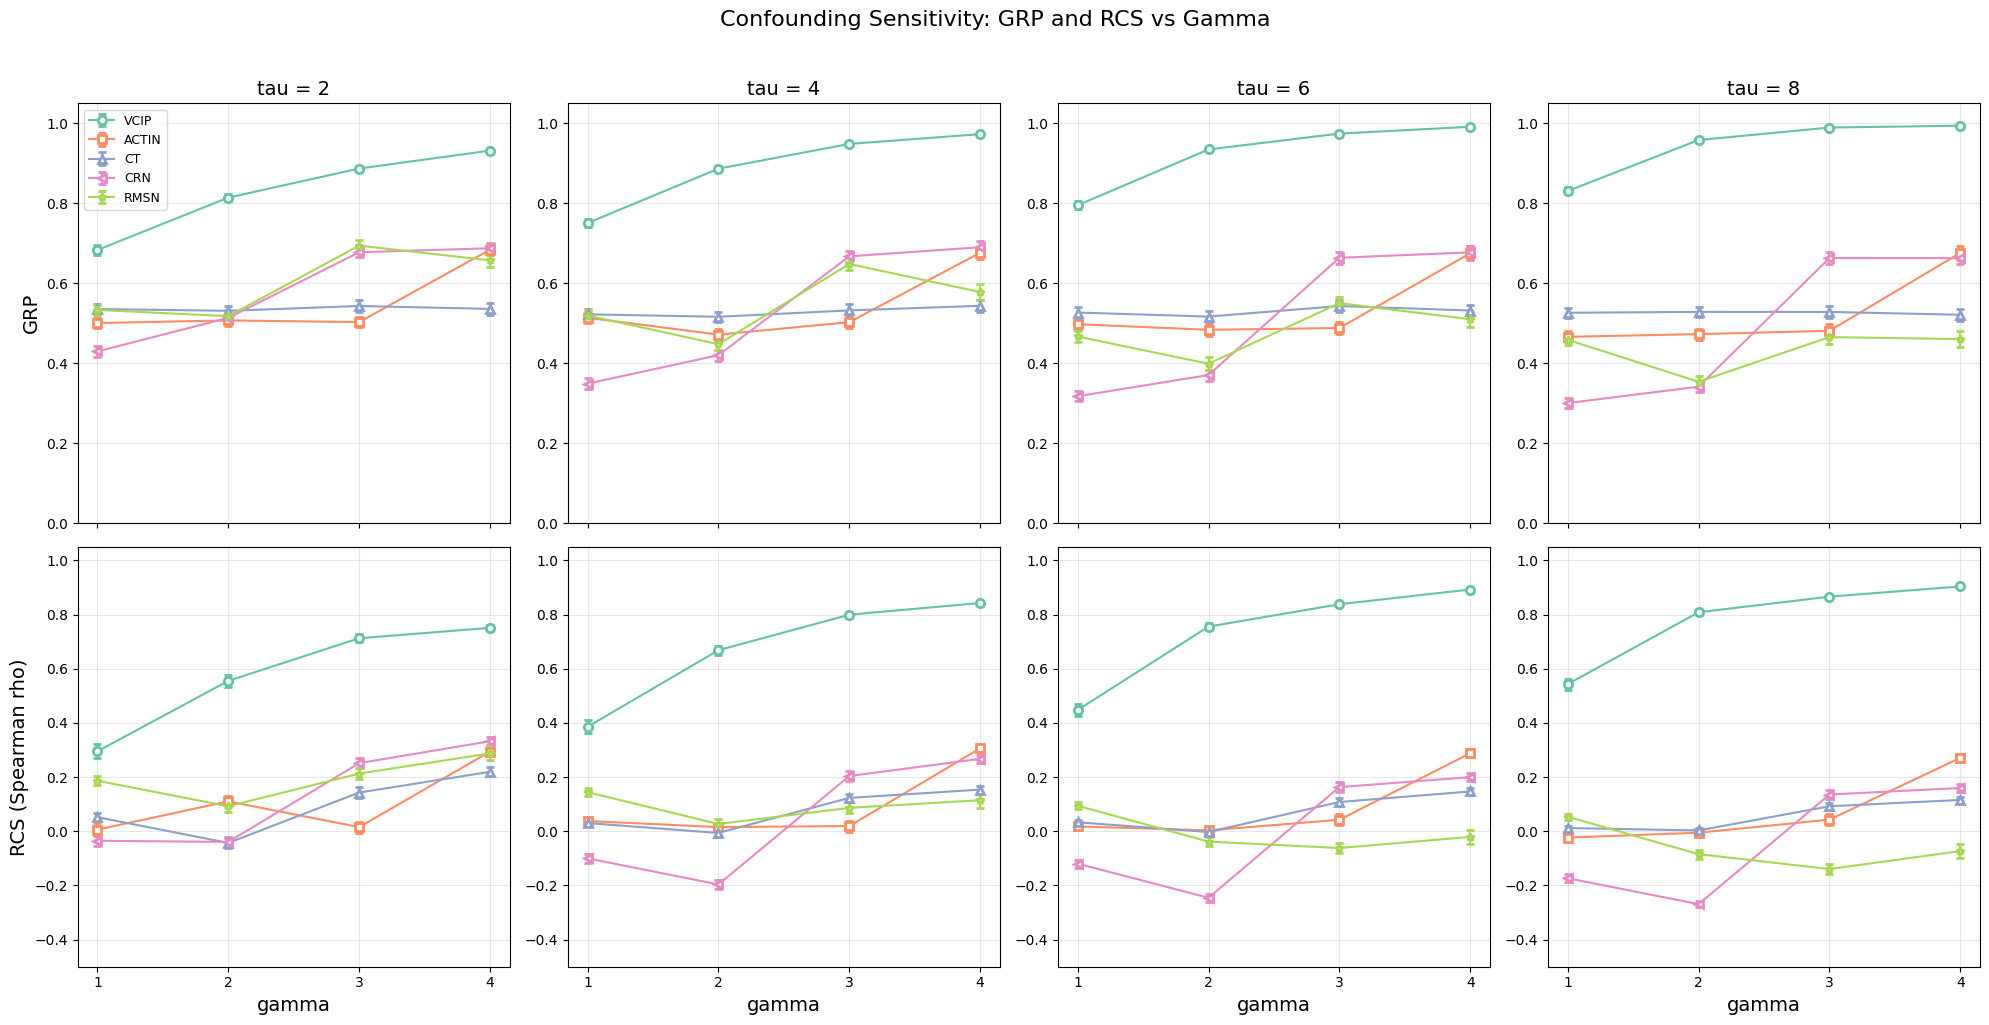

Confounding Sensitivity: GRP degradation (gamma=1 to gamma=4)
Model           tau=2      tau=4      tau=6      tau=8
--------------------------------------------------
VCIP          -0.248    -0.222    -0.196    -0.163
ACTIN         -0.183    -0.162    -0.177    -0.210
CT            -0.000    -0.021    -0.005    +0.005
CRN           -0.258    -0.341    -0.360    -0.362
RMSN          -0.124    -0.059    -0.043    -0.002

Key finding: VCIP advantage INCREASES with confounding strength.
At gamma=1 (low confounding), models are closer in GRP.
At gamma=4 (high confounding), VCIP dominates more clearly.


In [10]:
# Confounding sensitivity: GRP and RCS vs gamma for each model
fig, axes = plt.subplots(2, len(TAU_VALUES), figsize=(20, 10), sharex=True)
colors = sns.color_palette('Set2', len(MODELS_ORDER))
markers = ['o', 's', '^', '<', '*']

for t_idx, tau in enumerate(TAU_VALUES):
    ax_grp = axes[0, t_idx]
    ax_rcs = axes[1, t_idx]
    
    for m_idx, model in enumerate(MODELS_ORDER):
        grp_means, grp_stds = [], []
        rcs_means, rcs_stds = [], []
        gammas_avail = []
        
        for gamma in GAMMAS:
            if model not in cancer_all[gamma] or tau not in cancer_all[gamma][model]:
                continue
            cases = cancer_all[gamma][model][tau]
            ranks = np.array([c['true_sequence_rank'] for c in cases])
            grp_vals = (100 - ranks) / 99.0
            
            corrs = []
            for c in cases:
                rho, _ = stats.spearmanr(c['model_losses'], c['true_losses'])
                if not np.isnan(rho):
                    corrs.append(rho)
            
            grp_means.append(np.mean(grp_vals))
            grp_stds.append(np.std(grp_vals) / np.sqrt(len(grp_vals)))
            rcs_means.append(np.mean(corrs))
            rcs_stds.append(np.std(corrs) / np.sqrt(len(corrs)))
            gammas_avail.append(gamma)
        
        if gammas_avail:
            ax_grp.errorbar(gammas_avail, grp_means, yerr=grp_stds, label=model,
                           color=colors[m_idx], marker=markers[m_idx],
                           linewidth=1.5, markersize=6, capsize=3,
                           markerfacecolor='white', markeredgewidth=2)
            ax_rcs.errorbar(gammas_avail, rcs_means, yerr=rcs_stds, label=model,
                           color=colors[m_idx], marker=markers[m_idx],
                           linewidth=1.5, markersize=6, capsize=3,
                           markerfacecolor='white', markeredgewidth=2)
    
    ax_grp.set_title(f'tau = {tau}', fontsize=14)
    ax_grp.set_ylim(0, 1.05)
    ax_grp.grid(True, alpha=0.3)
    ax_grp.set_xticks(GAMMAS)
    if t_idx == 0:
        ax_grp.set_ylabel('GRP', fontsize=14)
        ax_grp.legend(fontsize=9)
    
    ax_rcs.set_xlabel('gamma', fontsize=14)
    ax_rcs.set_ylim(-0.5, 1.05)
    ax_rcs.grid(True, alpha=0.3)
    ax_rcs.set_xticks(GAMMAS)
    if t_idx == 0:
        ax_rcs.set_ylabel('RCS (Spearman rho)', fontsize=14)

fig.suptitle('Confounding Sensitivity: GRP and RCS vs Gamma', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('weakness_confounding_sensitivity.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Quantitative table
print('Confounding Sensitivity: GRP degradation (gamma=1 to gamma=4)')
print(f'{"Model":<10} {"tau=2":>10} {"tau=4":>10} {"tau=6":>10} {"tau=8":>10}')
print('-' * 50)
for model in MODELS_ORDER:
    row = f'{model:<10}'
    for tau in TAU_VALUES:
        if model in cancer_all[1] and tau in cancer_all[1][model] and \
           model in cancer_all[4] and tau in cancer_all[4][model]:
            grp_g1 = np.mean((100 - np.array([c['true_sequence_rank'] for c in cancer_all[1][model][tau]])) / 99)
            grp_g4 = np.mean((100 - np.array([c['true_sequence_rank'] for c in cancer_all[4][model][tau]])) / 99)
            row += f'{grp_g1 - grp_g4:>+10.3f}'
        else:
            row += f'{"N/A":>10}'
    print(row)

print()
print('Key finding: VCIP advantage INCREASES with confounding strength.')
print('At gamma=1 (low confounding), models are closer in GRP.')
print('At gamma=4 (high confounding), VCIP dominates more clearly.')

## 6. Synthesis: Ranked Weaknesses and Research Directions

In [11]:
# Compile all findings into a structured summary
weaknesses = [
    {
        'id': 'W1',
        'name': 'ELBO Bound Gap Inconsistency',
        'evidence': 'Cancer ELBO-True correlation analysis (Section 1a)',
        'severity': 'HIGH',
        'description': (
            'ELBO is a lower bound whose tightness varies per sequence. '
            'Ranking by ELBO is only valid if the bound gap is constant across '
            'intervention sequences, which is not guaranteed. Our Cancer analysis '
            'shows imperfect ELBO-to-true-loss correlation.'
        ),
        'direction': (
            'Tighter bounds (IWAE, flow-based), or direct likelihood estimation '
            'bypassing the variational bound.'
        ),
    },
    {
        'id': 'W2',
        'name': 'Rank Instability Across Seeds',
        'evidence': 'Cross-seed rank stability (Section 2)',
        'severity': 'MEDIUM',
        'description': (
            'The same individual can get substantially different ranks across '
            'random seeds, indicating that VCIP\'s ranking depends on initialization '
            'and training trajectory, not just the data.'
        ),
        'direction': (
            'Ensemble-based ranking (average ELBO across multiple models), '
            'or uncertainty-aware ranking with credible intervals.'
        ),
    },
    {
        'id': 'W3',
        'name': 'Single Target Outcome',
        'evidence': 'Theoretical analysis (Section 5), VCIP paper Eq. 19',
        'severity': 'HIGH',
        'description': (
            'VCIP optimizes for a single scalar target Y_{t+tau}. Clinical '
            'decisions involve multiple outcomes, trade-offs, and constraints '
            '(e.g., minimize blood pressure while avoiding renal failure).'
        ),
        'direction': (
            'Multi-objective ELBO with Pareto-optimal intervention ranking, '
            'or constraint-aware optimization.'
        ),
    },
    {
        'id': 'W4',
        'name': 'Perturbation-Dependent Evaluation',
        'evidence': 'ELBO separation analysis (Section 3)',
        'severity': 'MEDIUM',
        'description': (
            'GRP depends on the specific set of k=100 random perturbations. '
            'The metric is not a consistent estimator of intervention quality '
            'and may be biased by the perturbation distribution.'
        ),
        'direction': (
            'Gradient-based intervention optimization (already in paper Section 5.2) '
            'as primary evaluation, or importance-weighted GRP.'
        ),
    },
    {
        'id': 'W5',
        'name': 'Treatment Pattern Sensitivity',
        'evidence': 'Slice discovery (MIMIC analysis Section 8)',
        'severity': 'LOW-MEDIUM',
        'description': (
            'VCIP advantage is smallest for dual-treatment patients ("Both" pattern) '
            'at short horizons (tau=2, advantage=0.160 vs 0.218 for Neither). '
            'Complex treatment regimes may challenge the generative model.'
        ),
        'direction': (
            'Treatment-aware latent structure, or hierarchical models that '
            'separately encode treatment interactions.'
        ),
    },
    {
        'id': 'W6',
        'name': 'No Counterfactual Validation on Real Data',
        'evidence': 'MIMIC RCS analysis (all NaN)',
        'severity': 'HIGH',
        'description': (
            'On real-world data, true counterfactual outcomes are unobservable. '
            'GRP only measures whether the model prefers the observed sequence, '
            'not whether the recommended intervention would actually improve outcomes. '
            'This is a fundamental limitation of observational evaluation.'
        ),
        'direction': (
            'Off-policy evaluation methods (doubly robust estimators, CATE bounds), '
            'or prospective validation in clinical trials.'
        ),
    },
]

print('VCIP WEAKNESS ANALYSIS — RANKED SUMMARY')
print('=' * 80)
for w in weaknesses:
    print(f'\n[{w["id"]}] {w["name"]} (Severity: {w["severity"]})')
    print(f'    Evidence: {w["evidence"]}')
    print(f'    Issue: {w["description"][:120]}...')
    print(f'    Direction: {w["direction"][:120]}...')

print('\n' + '=' * 80)
print('\nMost promising research directions (by novelty x impact):')
print('  1. W1 + W2: Tighter variational bounds with uncertainty quantification')
print('  2. W3: Multi-outcome counterfactual intervention planning')
print('  3. W6: Off-policy evaluation for real-world validation')
print('  4. W5: Treatment-interaction-aware generative models')

VCIP WEAKNESS ANALYSIS — RANKED SUMMARY

[W1] ELBO Bound Gap Inconsistency (Severity: HIGH)
    Evidence: Cancer ELBO-True correlation analysis (Section 1a)
    Issue: ELBO is a lower bound whose tightness varies per sequence. Ranking by ELBO is only valid if the bound gap is constant ac...
    Direction: Tighter bounds (IWAE, flow-based), or direct likelihood estimation bypassing the variational bound....

[W2] Rank Instability Across Seeds (Severity: MEDIUM)
    Evidence: Cross-seed rank stability (Section 2)
    Issue: The same individual can get substantially different ranks across random seeds, indicating that VCIP's ranking depends on...
    Direction: Ensemble-based ranking (average ELBO across multiple models), or uncertainty-aware ranking with credible intervals....

[W3] Single Target Outcome (Severity: HIGH)
    Evidence: Theoretical analysis (Section 5), VCIP paper Eq. 19
    Issue: VCIP optimizes for a single scalar target Y_{t+tau}. Clinical decisions involve multiple out